# CHARM subvolume reconstruction power-ratio test

This notebook runs CHARM inference for one config and simulation id, reconstructs
`mock(reconst)` and `truth(reconst)` as 512 subvolume-local halo catalogs, builds
`truth(orig)` directly from the matching Rockstar catalog with the training-time
selection, and compares per-subvolume power-spectrum ratios.

Set `CONFIG_PATH` and `SIM_ID` in the next cell, then run top to bottom.

In [1]:
from pathlib import Path
import os
import sys
import warnings

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kwargs):
        return x

REPO_ROOT = Path("/mnt/ceph/users/spandey/CHARM_v2/CHARM").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "charm") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "charm"))

from charm.config_loader import load_config
from charm.run_charm_joint_ddp import build_model
from charm.run_inference_v2 import (
    build_cond_tensors,
    build_dm_velocity_interpolators,
    estimate_target_prior_from_cosmology,
    load_checkpoint,
    load_cosmology,
    load_fastpm,
    subvols_unpadded,
)
from charm.utils_data_prep_v2 import prep_halo_catalog

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.18,
})

/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# User parameters.
CONFIG_PATH = REPO_ROOT / "run_configs/TRAIN_CHARM_JOINT_v2vel_finetune2.yaml"
SIM_ID = 1901

# Leave as None to use <checkpoint_dir>/charm_joint_best_val.pth.
CHECKPOINT_PATH = None

# Binary prior controls. These mirror charm/run_inference_v2.py.
BINARY_TARGET_PRIOR = None
BINARY_PRIOR_CALIBRATOR = None
BINARY_TRAIN_PRIOR = None

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Power-spectrum settings for each 125 Mpc/h subvolume.
POWER_GRID = 64
K_MAX = 1.0
MAS = "TSC"
RSD_AXIS = 2
RATIO_YLIM = (0.5, 1.5)

FIG_PATH = REPO_ROOT / "notebooks/testing/reconstruct_subvolume_power_ratios.png"

In [3]:
def resolve_repo_path(path_like):
    """Resolve repo-relative config paths while preserving absolute paths."""
    if path_like is None:
        return None
    p = Path(path_like)
    return p if p.is_absolute() else (REPO_ROOT / p).resolve()


def resolve_best_checkpoint(cfg, explicit_path=None):
    """Return the best checkpoint path for the config run."""
    if explicit_path is not None:
        return resolve_repo_path(explicit_path)

    ckpt_dir = resolve_repo_path(cfg["train_settings"]["checkpoint_dir"])
    candidates = [
        ckpt_dir / "charm_joint_best_val.pth",
        ckpt_dir / "best_val.pth",
        ckpt_dir / "checkpoint_best.pth",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate

    best_like = sorted(ckpt_dir.glob("*best*.pth"))
    if best_like:
        return best_like[-1]
    raise FileNotFoundError(
        f"No best checkpoint found in {ckpt_dir}. Set CHECKPOINT_PATH explicitly."
    )


cfg = load_config(str(resolve_repo_path(CONFIG_PATH)))
sc = cfg["sim_settings"]
dc = cfg["data_settings"]
tc = cfg["train_settings"]

nb = int(sc["nb"])
ns_d = int(sc["ns_d"])
ns_h = int(sc["ns_h"])
nax = ns_h // nb
nsubs = nb ** 3
nvox = nax ** 3
Nmax = int(sc["Nmax"])
BoxSize = float(dc["BoxSize"])
Lsub = BoxSize / nb
z_snap = str(dc["z_snap"])
z = float(z_snap)

n_cnn_tot = sum(1 if lt == "cnn" else 2 for lt in sc["layers_types"])
n_pad = (int(sc["nf"]) - 1) // 2 * n_cnn_tot

z_by_snap = {4: 0.0, 3: 0.5, 2: 1.0, 1: 2.0, 0: 3.0, -1: 99.0}
redshift = z_by_snap[int(dc["snapnum"])]

lgMmin = float(sc["lgMmin"])
lgMmax = float(sc["lgMmax"])
vmin = float(sc["vmin"])
vmax = float(sc["vmax"])
cmin = float(sc["cmin"])
cmax = float(sc["cmax"])

ckpt_path = resolve_best_checkpoint(cfg, CHECKPOINT_PATH)

assert nb == 8 and nsubs == 512, f"Expected 8^3=512 subvolumes; got nb={nb}."
assert ns_d == ns_h, f"This notebook assumes matching DM and halo grids; got {ns_d} and {ns_h}."

print(f"config: {resolve_repo_path(CONFIG_PATH)}")
print(f"simulation id: {SIM_ID}")
print(f"checkpoint: {ckpt_path}")
print(f"subvolumes: {nsubs} x ({nax}^3 voxels), Lsub={Lsub:.3f} Mpc/h")
print(f"device: {DEVICE}")

config: /mnt/ceph/users/spandey/CHARM_v2/CHARM/run_configs/TRAIN_CHARM_JOINT_v2vel_finetune2.yaml
simulation id: 1901
checkpoint: /mnt/ceph/users/spandey/CHARM_v2/model_checkpoints/CHARM_JOINT_v2vel_finetune2/charm_joint_best_val.pth
subvolumes: 512 x (16^3 voxels), Lsub=125.000 Mpc/h
device: cuda


In [4]:
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def flat_subvolume_voxel_indices(nb, nax):
    """
    Return subvolume id, subvolume grid id, and local voxel id for the
    flattened CHARM ordering:

        subvol = jx*nb^2 + jy*nb + jz
        voxel  = vx*nax^2 + vy*nax + vz
    """
    nsubs = nb ** 3
    nvox = nax ** 3
    total = nsubs * nvox

    isub = np.arange(total, dtype=np.int64) // nvox
    ivox = np.arange(total, dtype=np.int64) % nvox

    jx = isub // (nb * nb)
    jy = (isub % (nb * nb)) // nb
    jz = isub % nb

    vx = ivox // (nax * nax)
    vy = (ivox % (nax * nax)) // nax
    vz = ivox % nax
    return isub, jx, jy, jz, vx, vy, vz


def new_catalog_lists(n):
    return [
        {"pos": [], "lgM": [], "vel": [], "conc": []}
        for _ in range(n)
    ]


def append_grouped(cats, sub_ids, pos, lgM, vel, conc):
    """Append halo arrays to per-subvolume list-backed catalogs."""
    if len(sub_ids) == 0:
        return
    order = np.argsort(sub_ids, kind="mergesort")
    sid_sorted = sub_ids[order]
    cuts = np.r_[0, np.flatnonzero(sid_sorted[1:] != sid_sorted[:-1]) + 1, len(order)]

    for start, end in zip(cuts[:-1], cuts[1:]):
        sid = int(sid_sorted[start])
        idx = order[start:end]
        cats[sid]["pos"].append(pos[idx].astype(np.float32, copy=False))
        cats[sid]["lgM"].append(lgM[idx].astype(np.float32, copy=False))
        cats[sid]["vel"].append(vel[idx].astype(np.float32, copy=False))
        cats[sid]["conc"].append(conc[idx].astype(np.float32, copy=False))


def finalize_catalogs(cats):
    """Convert list-backed per-subvolume catalogs to normal arrays."""
    out = []
    for cat in cats:
        if cat["pos"]:
            out.append({
                "pos": np.concatenate(cat["pos"], axis=0).astype(np.float32),
                "lgM": np.concatenate(cat["lgM"], axis=0).astype(np.float32),
                "vel": np.concatenate(cat["vel"], axis=0).astype(np.float32),
                "conc": np.concatenate(cat["conc"], axis=0).astype(np.float32),
            })
        else:
            out.append({
                "pos": np.zeros((0, 3), dtype=np.float32),
                "lgM": np.zeros(0, dtype=np.float32),
                "vel": np.zeros((0, 3), dtype=np.float32),
                "conc": np.zeros(0, dtype=np.float32),
            })
    return out


def reconstruct_sample_out_by_subvolume(sample_out, vel_interps):
    """
    Decode a CHARM sample_out-like dict into 512 subvolume-local catalogs.

    Positions stored in the returned catalogs are local to each subvolume.
    Full-box positions are constructed only internally for FastPM velocity
    interpolation, matching the inference decoder.
    """
    total = nsubs * nvox
    cell = BoxSize / ns_h
    v_range = vmax - vmin

    ntot = np.clip(
        np.rint(to_numpy(sample_out["ntot"][0]).reshape(total)),
        0,
        Nmax,
    ).astype(np.int16)

    m1 = np.clip(to_numpy(sample_out["m1"][0]).reshape(total), 0.0, 1.0).astype(np.float32)
    mdiff = np.clip(
        to_numpy(sample_out["mdiff"][0]).reshape(total, Nmax - 1),
        0.0,
        1.0,
    ).astype(np.float32)
    vel_norm = np.clip(
        to_numpy(sample_out["vel"][0]).reshape(total, Nmax * 3),
        -0.5,
        0.5,
    ).astype(np.float32)
    conc_norm = np.clip(
        to_numpy(sample_out["conc"][0]).reshape(total, Nmax),
        0.0,
        1.0,
    ).astype(np.float32)
    pos_norm = np.clip(
        to_numpy(sample_out["pos"][0]).reshape(total, Nmax * 3),
        -0.5,
        0.5,
    ).astype(np.float32)

    M_norm = np.zeros((total, Nmax), dtype=np.float32)
    M_norm[:, 0] = m1
    for ih in range(1, Nmax):
        M_norm[:, ih] = np.clip(M_norm[:, ih - 1] - mdiff[:, ih - 1], 0.0, 1.0)
    lgM_grid = M_norm * (lgMmax - lgMmin) + lgMmin

    isub, jx, jy, jz, vx, vy, vz = flat_subvolume_voxel_indices(nb, nax)
    cats = new_catalog_lists(nsubs)

    for ih in range(Nmax):
        has_halo = ntot > ih
        if not np.any(has_halo):
            continue

        px = pos_norm[has_halo, ih * 3 + 0]
        py = pos_norm[has_halo, ih * 3 + 1]
        pz = pos_norm[has_halo, ih * 3 + 2]

        # Local positions: add only the local voxel offset inside this
        # subvolume. Do not add the full-box subvolume origin here.
        x_local = ((vx[has_halo] + px) * cell) % Lsub
        y_local = ((vy[has_halo] + py) * cell) % Lsub
        z_local = ((vz[has_halo] + pz) * cell) % Lsub
        pos_local = np.stack([x_local, y_local, z_local], axis=1).astype(np.float32)

        # Full-box positions are needed only to evaluate the FastPM
        # velocity residual at the same physical point used in training.
        x_full = (((jx[has_halo] * nax + vx[has_halo]) + px) * cell) % BoxSize
        y_full = (((jy[has_halo] * nax + vy[has_halo]) + py) * cell) % BoxSize
        z_full = (((jz[has_halo] * nax + vz[has_halo]) + pz) * cell) % BoxSize
        pos_full = np.stack([x_full, y_full, z_full], axis=1).astype(np.float32)

        v_dm = np.stack([interp(pos_full) for interp in vel_interps], axis=1).astype(np.float32)
        v_diff = vel_norm[has_halo, ih * 3: ih * 3 + 3] * v_range
        vel_phys = (v_dm - v_diff).astype(np.float32)

        lgM = lgM_grid[has_halo, ih].astype(np.float32)
        conc = (conc_norm[has_halo, ih] * (cmax - cmin) + cmin).astype(np.float32)
        append_grouped(cats, isub[has_halo], pos_local, lgM, vel_phys, conc)

    return finalize_catalogs(cats)

In [5]:
print("Loading FastPM density and velocity fields...")
rho, vel = load_fastpm(dc["fastpm_dir"], SIM_ID, ns_d, z_snap)
cosmo_vals = load_cosmology(dc["lh_cosmo_file"], SIM_ID)
vel_interps = build_dm_velocity_interpolators(vel, BoxSize)

print("Building CHARM conditioning tensors...")
cond_x, cond_x_nsh, cond_cosmo = build_cond_tensors(
    rho, vel, cosmo_vals, nb, nax, n_pad
)
cond_x = cond_x.to(DEVICE)
cond_x_nsh = cond_x_nsh.to(DEVICE)
cond_cosmo = cond_cosmo.to(DEVICE)

print("Loading model and best checkpoint...")
model = build_model(cfg).to(DEVICE)
model = load_checkpoint(model, str(ckpt_path), torch.device(DEVICE))
model.eval()

if BINARY_TRAIN_PRIOR is not None:
    model.binary_train_prior = float(BINARY_TRAIN_PRIOR)

binary_target_prior = BINARY_TARGET_PRIOR
if model.binary_train_prior is not None and binary_target_prior is None:
    cal_path = resolve_repo_path(BINARY_PRIOR_CALIBRATOR) if BINARY_PRIOR_CALIBRATOR else ckpt_path.parent / "binary_prior_calibrator.npz"
    if cal_path.exists():
        binary_target_prior, info = estimate_target_prior_from_cosmology(
            cosmo_vals,
            str(cal_path),
        )
        print(
            "Auto-estimated binary_target_prior="
            f"{binary_target_prior:.3e} from {cal_path}"
        )
    else:
        warnings.warn(
            "Model has a binary_train_prior but no binary target prior or "
            f"calibrator was found at {cal_path}; using uncorrected occupancy."
        )

print("Running inference over all 512 subvolumes...")
with torch.no_grad():
    sample_out_mock = model.sample(
        cond_x,
        cond_x_nsh,
        cond_cosmo,
        sample_binary=True,
        sample_multi=True,
        sample_m1=True,
        sample_mdiff=True,
        sample_vel=True,
        sample_conc=True,
        sample_pos=True,
        use_truth_masses=False,
        binary_target_prior=binary_target_prior,
    )

mock_reconst = reconstruct_sample_out_by_subvolume(sample_out_mock, vel_interps)
print(f"mock(reconst): {sum(len(c['pos']) for c in mock_reconst):,} halos")

Loading FastPM density and velocity fields...
Building CHARM conditioning tensors...
Loading model and best checkpoint...
  Loaded checkpoint: phase=0, step=580, val_loss_min=-16.2542
Running inference over all 512 subvolumes...
mock(reconst): 879,897 halos


In [6]:
def load_processed_halo_h5():
    """Load the per-simulation HDF5 produced by process_halos_quijote_v2.py."""
    halo_dir = resolve_repo_path(dc["halo_hdf5_dir"])
    fpath = halo_dir / str(SIM_ID) / f"halos_rockstar_200c_z{redshift}.h5"
    if not fpath.exists():
        raise FileNotFoundError(f"Processed halo HDF5 not found: {fpath}")

    out = {}
    with h5py.File(fpath, "r") as f:
        for key in [
            "N_halos",
            "M_halos",
            "pos_halos",
            "c_halos_sim",
            "v_halos_diff",
        ]:
            out[key] = f[key][:]
    return out, fpath


print("Loading training-format truth HDF5 and rebuilding normalized targets...")
halos_full, halo_h5_path = load_processed_halo_h5()
halo_sub = {key: subvols_unpadded(value, nb, nax) for key, value in halos_full.items()}

cosmo_sub = np.broadcast_to(
    cosmo_vals[None, None, None, None, :],
    (nsubs, nax, nax, nax, len(cosmo_vals)),
).copy()

truth_targets = prep_halo_catalog(
    df_Mh=halo_sub["M_halos"].astype(np.float32),
    df_Nh=halo_sub["N_halos"].astype(np.int16),
    cosmo=cosmo_sub.astype(np.float32),
    Mmin=lgMmin,
    Mmax=lgMmax,
    Nmax=Nmax,
    rescale_sub=float(sc.get("rescale_sub", 0.0)),
    df_v=halo_sub["v_halos_diff"].astype(np.float32),
    df_c=halo_sub["c_halos_sim"].astype(np.float32),
    df_pos=halo_sub["pos_halos"].astype(np.float32),
    vmin=vmin,
    vmax=vmax,
    cmin=cmin,
    cmax=cmax,
)

sample_out_truth = {
    "ntot": [truth_targets["N_halos"].reshape(-1).astype(np.float32)],
    "m1": [truth_targets["M1_norm"].reshape(-1).astype(np.float32)],
    "mdiff": [truth_targets["Mdiff_norm"].reshape(-1, Nmax - 1).astype(np.float32)],
    "vel": [truth_targets["v_norm"].reshape(-1, Nmax * 3).astype(np.float32)],
    "conc": [truth_targets["c_norm"].reshape(-1, Nmax).astype(np.float32)],
    "pos": [truth_targets["pos_norm"].reshape(-1, Nmax * 3).astype(np.float32)],
}

truth_reconst = reconstruct_sample_out_by_subvolume(sample_out_truth, vel_interps)
print(f"truth(reconst): {sum(len(c['pos']) for c in truth_reconst):,} halos")
print(f"source HDF5: {halo_h5_path}")

Loading training-format truth HDF5 and rebuilding normalized targets...
truth(reconst): 878,924 halos
source HDF5: /mnt/ceph/users/spandey/CHARM_v2/data/halos_Mmin5e12/1901/halos_rockstar_200c_z0.5.h5


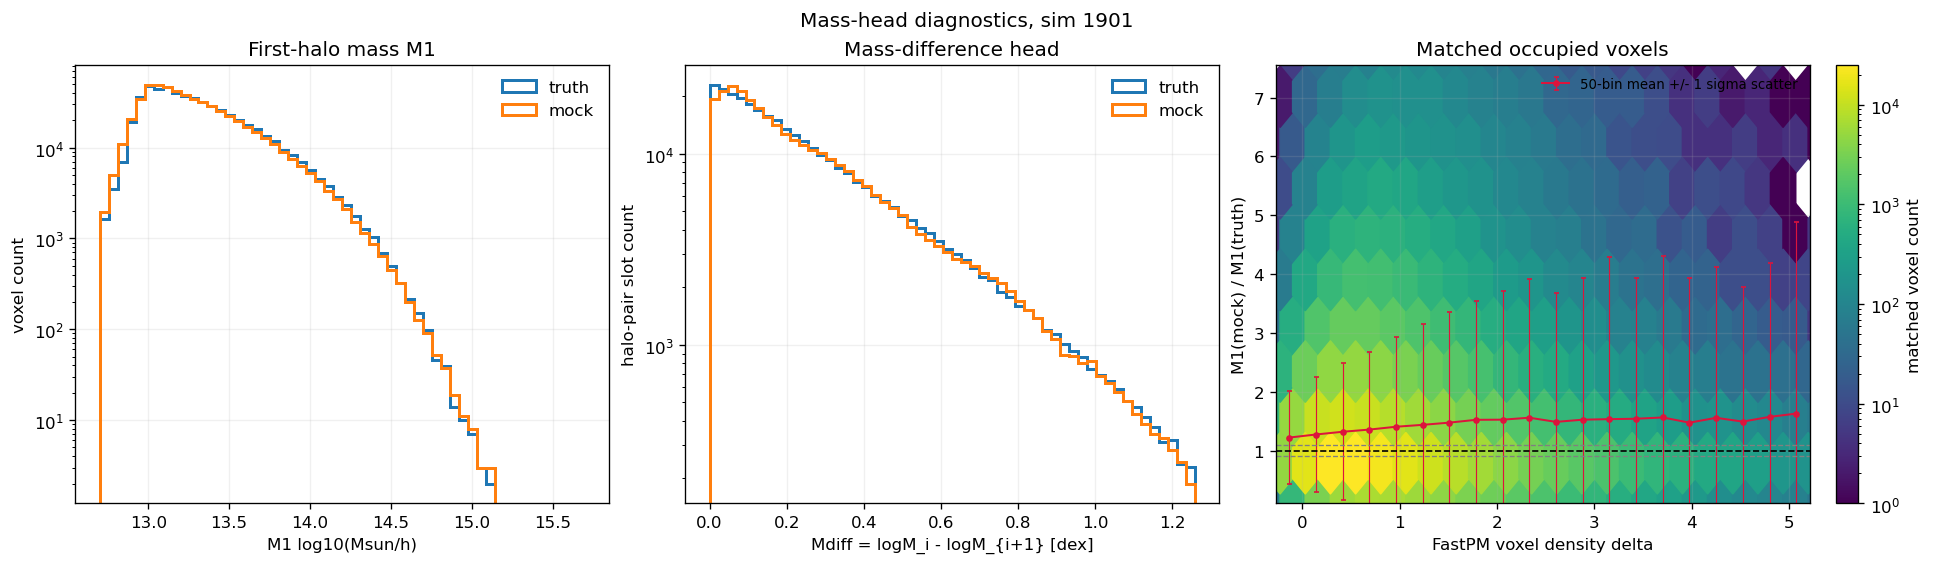

Matched occupied voxels for M1 ratio: 331,985
Saved mass-head diagnostics to /mnt/ceph/users/spandey/CHARM_v2/CHARM/notebooks/testing/reconstruct_subvolume_mass_head_diagnostics.png


In [7]:
# Mass-head diagnostics: M1, Mdiff, and M1 ratio versus PM density.
# This uses the same flattened subvolume-major voxel ordering as CHARM sampling.
N_DELTA_BINS = 20
DELTA_BIN_PERCENTILES = (0.5, 99.5)
MASS_DIAG_FIG_PATH = REPO_ROOT / "notebooks/testing/reconstruct_subvolume_mass_head_diagnostics.png"

ntot_mock = np.clip(
    np.rint(to_numpy(sample_out_mock["ntot"][0]).reshape(-1)),
    0,
    Nmax,
).astype(np.int16)
ntot_truth = truth_targets["N_halos"].reshape(-1).astype(np.int16)

m1_mock_norm = np.clip(
    to_numpy(sample_out_mock["m1"][0]).reshape(-1),
    0.0,
    1.0,
).astype(np.float32)
m1_truth_norm = np.clip(
    truth_targets["M1_norm"].reshape(-1).astype(np.float32),
    0.0,
    1.0,
)

mdiff_mock_norm = np.clip(
    to_numpy(sample_out_mock["mdiff"][0]).reshape(-1, Nmax - 1),
    0.0,
    1.0,
).astype(np.float32)
mdiff_truth_norm = np.clip(
    truth_targets["Mdiff_norm"].reshape(-1, Nmax - 1).astype(np.float32),
    0.0,
    1.0,
)

lgM_range = lgMmax - lgMmin
m1_mock_lgM = m1_mock_norm * lgM_range + lgMmin
m1_truth_lgM = m1_truth_norm * lgM_range + lgMmin

m1_mock_vals = m1_mock_lgM[ntot_mock > 0]
m1_truth_vals = m1_truth_lgM[ntot_truth > 0]

mdiff_slot = np.arange(Nmax - 1)[None, :]
mdiff_mock_mask = mdiff_slot < np.clip(ntot_mock - 1, 0, None)[:, None]
mdiff_truth_mask = mdiff_slot < np.clip(ntot_truth - 1, 0, None)[:, None]
mdiff_mock_dex = (mdiff_mock_norm * lgM_range)[mdiff_mock_mask]
mdiff_truth_dex = (mdiff_truth_norm * lgM_range)[mdiff_truth_mask]

# PM density in the exact flattened order used by sample_out arrays.
delta_flat = subvols_unpadded(rho, nb, nax).reshape(-1).astype(np.float32)

# Matched-voxel M1 ratio. This isolates mass-head performance from pure
# occupancy disagreements by requiring both mock and truth to have M1.
matched = (
    (ntot_mock > 0)
    & (ntot_truth > 0)
    & np.isfinite(delta_flat)
    & np.isfinite(m1_mock_lgM)
    & np.isfinite(m1_truth_lgM)
)
delta_match = delta_flat[matched]
m1_ratio_match = 10.0 ** (m1_mock_lgM[matched] - m1_truth_lgM[matched])
if len(m1_ratio_match) == 0:
    raise RuntimeError("No matched occupied voxels are available for M1 ratio diagnostics.")

dlo, dhi = np.nanpercentile(delta_match, DELTA_BIN_PERCENTILES)
delta_edges = np.linspace(dlo, dhi, N_DELTA_BINS + 1)
delta_centers = 0.5 * (delta_edges[:-1] + delta_edges[1:])
bin_mean = np.full(N_DELTA_BINS, np.nan, dtype=np.float64)
bin_sigma = np.full(N_DELTA_BINS, np.nan, dtype=np.float64)
bin_count = np.zeros(N_DELTA_BINS, dtype=np.int64)

for ib in range(N_DELTA_BINS):
    if ib == N_DELTA_BINS - 1:
        in_bin = (delta_match >= delta_edges[ib]) & (delta_match <= delta_edges[ib + 1])
    else:
        in_bin = (delta_match >= delta_edges[ib]) & (delta_match < delta_edges[ib + 1])
    vals = m1_ratio_match[in_bin]
    vals = vals[np.isfinite(vals)]
    bin_count[ib] = len(vals)
    if len(vals) >= 5:
        bin_mean[ib] = np.mean(vals)
        bin_sigma[ib] = np.std(vals, ddof=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)

m1_bins = np.linspace(lgMmin, lgMmax, 55)
axes[0].hist(m1_truth_vals, bins=m1_bins, histtype="step", lw=1.8, color="tab:blue", label="truth")
axes[0].hist(m1_mock_vals, bins=m1_bins, histtype="step", lw=1.8, color="tab:orange", label="mock")
axes[0].set_yscale("log")
axes[0].set_xlabel("M1 log10(Msun/h)")
axes[0].set_ylabel("voxel count")
axes[0].set_title("First-halo mass M1")
axes[0].legend(frameon=False)

mdiff_hi = max(
    np.nanpercentile(mdiff_truth_dex, 99.5) if len(mdiff_truth_dex) else 0.1,
    np.nanpercentile(mdiff_mock_dex, 99.5) if len(mdiff_mock_dex) else 0.1,
)
mdiff_bins = np.linspace(0.0, mdiff_hi, 55)
axes[1].hist(mdiff_truth_dex, bins=mdiff_bins, histtype="step", lw=1.8, color="tab:blue", label="truth")
axes[1].hist(mdiff_mock_dex, bins=mdiff_bins, histtype="step", lw=1.8, color="tab:orange", label="mock")
axes[1].set_yscale("log")
axes[1].set_xlabel("Mdiff = logM_i - logM_{i+1} [dex]")
axes[1].set_ylabel("halo-pair slot count")
axes[1].set_title("Mass-difference head")
axes[1].legend(frameon=False)

ylo, yhi = np.nanpercentile(m1_ratio_match, [1, 99])
ylo = min(0.1, max(0.0, ylo))
yhi = max(1.2, yhi)
hb = axes[2].hexbin(delta_match, m1_ratio_match, gridsize=75, bins="log", mincnt=1, cmap="viridis")
good_bins = np.isfinite(bin_mean) & np.isfinite(bin_sigma)
axes[2].errorbar(
    delta_centers[good_bins],
    bin_mean[good_bins],
    yerr=bin_sigma[good_bins],
    fmt="o-",
    ms=3,
    lw=1.2,
    color="crimson",
    ecolor="crimson",
    elinewidth=0.7,
    capsize=1.5,
    label="50-bin mean +/- 1 sigma scatter",
)
axes[2].axhline(1.0, color="black", ls="--", lw=1.0)
axes[2].axhline(0.9, color="0.5", ls="--", lw=0.8)
axes[2].axhline(1.1, color="0.5", ls="--", lw=0.8)
axes[2].set_xlim(dlo, dhi)
axes[2].set_ylim(ylo, yhi)
axes[2].set_xlabel("FastPM voxel density delta")
axes[2].set_ylabel("M1(mock) / M1(truth)")
axes[2].set_title("Matched occupied voxels")
axes[2].legend(frameon=False, fontsize=8)
fig.colorbar(hb, ax=axes[2], label="matched voxel count")

fig.suptitle(f"Mass-head diagnostics, sim {SIM_ID}", fontsize=12)
# fig.savefig(MASS_DIAG_FIG_PATH, bbox_inches="tight")
plt.show()

print(f"Matched occupied voxels for M1 ratio: {matched.sum():,}")
print(f"Saved mass-head diagnostics to {MASS_DIAG_FIG_PATH}")

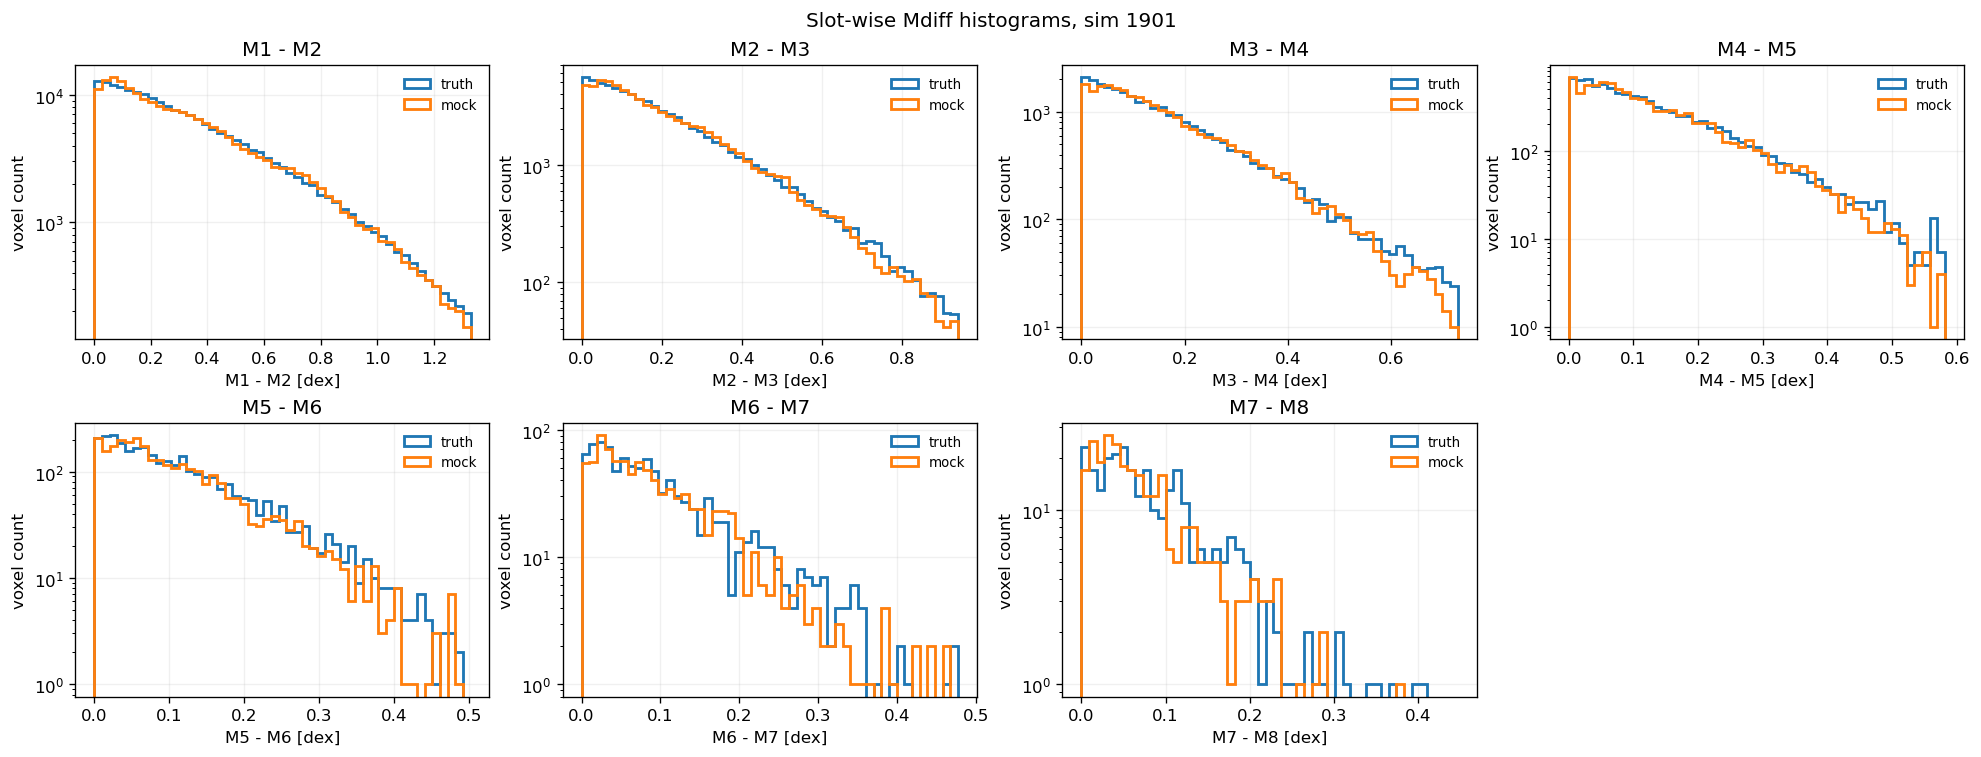

Saved slot-wise Mdiff histograms to /mnt/ceph/users/spandey/CHARM_v2/CHARM/notebooks/testing/reconstruct_subvolume_mdiff_slot_histograms.png


In [8]:
# Slot-wise Mdiff diagnostics: M1-M2, M2-M3, ... separately.
MASS_MDIFF_SLOT_FIG_PATH = REPO_ROOT / "notebooks/testing/reconstruct_subvolume_mdiff_slot_histograms.png"
lgM_range = lgMmax - lgMmin

ntot_mock_slot = np.clip(
    np.rint(to_numpy(sample_out_mock["ntot"][0]).reshape(-1)),
    0,
    Nmax,
).astype(np.int16)
ntot_truth_slot = truth_targets["N_halos"].reshape(-1).astype(np.int16)

mdiff_mock_norm_slot = np.clip(
    to_numpy(sample_out_mock["mdiff"][0]).reshape(-1, Nmax - 1),
    0.0,
    1.0,
).astype(np.float32)
mdiff_truth_norm_slot = np.clip(
    truth_targets["Mdiff_norm"].reshape(-1, Nmax - 1).astype(np.float32),
    0.0,
    1.0,
)

n_mdiff_slots = Nmax - 1
ncols = min(4, n_mdiff_slots)
nrows = int(np.ceil(n_mdiff_slots / ncols))
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.1 * ncols, 3.1 * nrows),
    sharey=False,
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()

for islot in range(n_mdiff_slots):
    ax = axes[islot]
    mock_mask = ntot_mock_slot > (islot + 1)
    truth_mask = ntot_truth_slot > (islot + 1)
    mock_vals = (mdiff_mock_norm_slot[:, islot] * lgM_range)[mock_mask]
    truth_vals = (mdiff_truth_norm_slot[:, islot] * lgM_range)[truth_mask]

    hi_candidates = []
    if len(mock_vals):
        hi_candidates.append(np.nanpercentile(mock_vals, 99.5))
    if len(truth_vals):
        hi_candidates.append(np.nanpercentile(truth_vals, 99.5))
    hi = max(hi_candidates + [0.05])
    bins = np.linspace(0.0, hi, 50)

    ax.hist(truth_vals, bins=bins, histtype="step", lw=1.7, color="tab:blue", label="truth")
    ax.hist(mock_vals, bins=bins, histtype="step", lw=1.7, color="tab:orange", label="mock")
    ax.set_yscale("log")
    ax.set_xlabel(f"M{islot + 1} - M{islot + 2} [dex]")
    ax.set_ylabel("voxel count")
    ax.set_title(f"M{islot + 1} - M{islot + 2}")
    ax.legend(frameon=False, fontsize=8)

for ax in axes[n_mdiff_slots:]:
    ax.axis("off")

fig.suptitle(f"Slot-wise Mdiff histograms, sim {SIM_ID}", fontsize=12)
fig.savefig(MASS_MDIFF_SLOT_FIG_PATH, bbox_inches="tight")
plt.show()

print(f"Saved slot-wise Mdiff histograms to {MASS_MDIFF_SLOT_FIG_PATH}")


In [9]:
def read_rockstar_200c_local(snapdir, snapnum):
    """Read a Rockstar *_pid.list catalog with the same columns used in data prep."""
    fpath = Path(snapdir) / f"out_{snapnum}_pid.list"
    if not fpath.exists():
        raise FileNotFoundError(f"Rockstar catalog not found: {fpath}")

    header = None
    with fpath.open() as f:
        for line in f:
            if line.startswith("#") and "ID" in line:
                header = line.lstrip("#").split()
                break
    if header is None:
        raise ValueError(f"Could not parse header from {fpath}")

    data = np.loadtxt(fpath, comments="#")
    data = np.atleast_2d(data)
    data = data[data[:, -1] == -1]

    col = header.index
    pos = data[:, col("X"): col("Z") + 1].astype(np.float32)
    vel = data[:, col("VX"): col("VZ") + 1].astype(np.float32)
    mass = data[:, col("M200c")].astype(np.float32)
    Rs = data[:, col("Rs")].astype(np.float32)
    return pos, vel, mass, Rs


def load_truth_orig_subvolumes():
    """
    Read raw Rockstar halos and apply the same selection used to build
    training targets:

    - parent halos only, handled inside read_rockstar_200c
    - M200c > data_settings.Mmin_cut
    - rounded NGP voxel assignment, matching NGP_xyz_prop
    - sort by mass within each voxel and keep only the top Nmax halos
    - split by the rounded voxel's 8^3 subvolume id
    """
    snapdir = resolve_repo_path(dc["rockstar_dir"]) / str(SIM_ID)
    pos, vel_true, mass, _ = read_rockstar_200c_local(str(snapdir), int(dc["snapnum"]))

    keep_mass = mass > float(dc["Mmin_cut"])
    pos = pos[keep_mass].astype(np.float32, copy=False)
    vel_true = vel_true[keep_mass].astype(np.float32, copy=False)
    mass = mass[keep_mass].astype(np.float32, copy=False)
    lgM = np.log10(mass).astype(np.float32)

    cell = BoxSize / ns_h
    vox = np.floor(pos / cell + 0.5).astype(np.int64) % ns_h
    ix, iy, iz = vox[:, 0], vox[:, 1], vox[:, 2]
    lin_vox = ix * ns_h * ns_h + iy * ns_h + iz

    # Sort by voxel id and descending mass; rank then clips to Nmax.
    order = np.lexsort((-mass, lin_vox))
    if len(order) == 0:
        return finalize_catalogs(new_catalog_lists(nsubs)), snapdir
    lin_sorted = lin_vox[order]
    group_start = np.empty(len(order), dtype=bool)
    group_start[0] = True
    group_start[1:] = lin_sorted[1:] != lin_sorted[:-1]
    first_in_group = np.maximum.accumulate(
        np.where(group_start, np.arange(len(order)), 0)
    )
    rank_in_voxel = np.arange(len(order)) - first_in_group
    keep = order[rank_in_voxel < Nmax]

    pos = pos[keep]
    vel_true = vel_true[keep]
    lgM = lgM[keep]
    ix, iy, iz = ix[keep], iy[keep], iz[keep]

    jx = ix // nax
    jy = iy // nax
    jz = iz // nax
    sub_id = (jx * nb * nb + jy * nb + jz).astype(np.int64)

    origin = np.stack([jx, jy, jz], axis=1).astype(np.float32) * Lsub
    pos_local = (pos - origin) % Lsub

    cats = new_catalog_lists(nsubs)
    conc_placeholder = np.full(len(pos_local), np.nan, dtype=np.float32)
    append_grouped(cats, sub_id, pos_local, lgM, vel_true, conc_placeholder)
    return finalize_catalogs(cats), snapdir


print("Loading truth(orig) from raw Rockstar and applying training selection...")
truth_orig, rockstar_path = load_truth_orig_subvolumes()
print(f"truth(orig): {sum(len(c['pos']) for c in truth_orig):,} halos")
print(f"source Rockstar directory: {rockstar_path}")

Loading truth(orig) from raw Rockstar and applying training selection...
truth(orig): 878,924 halos
source Rockstar directory: /mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/latin_hypercube_HR/1901


In [10]:
def density_field(pos, weights, Ng, box_size, MAS="TSC"):
    """Paint a halo catalog to an overdensity grid."""
    import MAS_library as MASL

    if len(pos) == 0:
        return None
    delta = np.zeros((Ng, Ng, Ng), dtype=np.float32)
    pos32 = np.ascontiguousarray(pos.astype(np.float32))
    box32 = np.float32(box_size)
    if weights is None:
        MASL.MA(pos32, delta, box32, MAS)
    else:
        w32 = np.ascontiguousarray(weights.astype(np.float32))
        MASL.MA(pos32, delta, box32, MAS, W=w32)

    mean = delta.mean(dtype=np.float64)
    if not np.isfinite(mean) or mean <= 0.0:
        return None
    return (delta / mean - 1.0).astype(np.float32)


def power_spectrum(cat, weights=None):
    """Return real-space monopole P(k) for one subvolume catalog."""
    import Pk_library as PKL

    delta = density_field(cat["pos"], weights, POWER_GRID, Lsub, MAS=MAS)
    if delta is None:
        return np.array([], dtype=np.float32), np.array([], dtype=np.float32)
    pk = PKL.Pk(delta, np.float32(Lsub), axis=RSD_AXIS, MAS=MAS, threads=1, verbose=False)
    k = pk.k3D
    P = pk.Pk[:, 0]
    sel = (k > 0) & (k <= K_MAX) & np.isfinite(P)
    return k[sel].astype(np.float32), P[sel].astype(np.float32)


def apply_rsd_local(cat):
    """Apply redshift-space distortions along RSD_AXIS inside a subvolume."""
    Omega_m = float(cosmo_vals[0])
    Ez = np.sqrt(Omega_m * (1.0 + z) ** 3 + (1.0 - Omega_m))
    H_eff = 100.0 * Ez
    pos_rsd = cat["pos"].copy()
    pos_rsd[:, RSD_AXIS] = (
        pos_rsd[:, RSD_AXIS]
        + cat["vel"][:, RSD_AXIS] * (1.0 + z) / H_eff
    ) % Lsub
    return {**cat, "pos": pos_rsd}


def power_multipoles(cat, weights=None):
    """Return redshift-space P0 and P2 for one subvolume catalog."""
    import Pk_library as PKL

    rsd_cat = apply_rsd_local(cat)
    delta = density_field(rsd_cat["pos"], weights, POWER_GRID, Lsub, MAS=MAS)
    if delta is None:
        z0 = np.array([], dtype=np.float32)
        return z0, z0, z0

    pk = PKL.Pk(delta, np.float32(Lsub), axis=RSD_AXIS, MAS=MAS, threads=1, verbose=False)
    k = pk.k3D
    P0 = pk.Pk[:, 0]
    P2 = pk.Pk[:, 1]
    sel = (k > 0) & (k <= K_MAX) & np.isfinite(P0) & np.isfinite(P2)
    return k[sel].astype(np.float32), P0[sel].astype(np.float32), P2[sel].astype(np.float32)


def statistic(cat, name):
    if name == "real_unweighted":
        return power_spectrum(cat, weights=None)
    if name == "real_mass_weighted":
        weights = 10.0 ** cat["lgM"] / 1.0e14
        return power_spectrum(cat, weights=weights)
    if name == "rsd_p0":
        k, P0, _ = power_multipoles(cat, weights=None)
        return k, P0
    if name == "rsd_p2":
        k, _, P2 = power_multipoles(cat, weights=None)
        return k, P2
    raise ValueError(name)


def interp_to_grid(k, y, k_ref):
    out = np.full_like(k_ref, np.nan, dtype=np.float64)
    good = np.isfinite(k) & np.isfinite(y)
    if np.count_nonzero(good) < 2:
        return out
    kg = k[good]
    yg = y[good]
    order = np.argsort(kg)
    kg = kg[order]
    yg = yg[order]
    inside = (k_ref >= kg[0]) & (k_ref <= kg[-1])
    out[inside] = np.interp(k_ref[inside], kg, yg)
    return out


def ratio_from_tables(num_table, den_table, k_ref, floor_frac=1.0e-8):
    rows = []
    for (kn, yn), (kd, yd) in zip(num_table, den_table):
        num = interp_to_grid(kn, yn, k_ref)
        den = interp_to_grid(kd, yd, k_ref)
        floor = floor_frac * np.nanmax(np.abs(den)) if np.any(np.isfinite(den)) else np.inf
        with np.errstate(divide="ignore", invalid="ignore"):
            ratio = np.where(np.abs(den) > floor, num / den, np.nan)
        rows.append(ratio)
    return np.vstack(rows)


stat_specs = [
    ("real_unweighted", "Real-space P(k), unweighted"),
    ("real_mass_weighted", "Real-space P(k), mass weighted"),
    ("rsd_p0", "Redshift-space monopole P0"),
    ("rsd_p2", "Redshift-space quadrupole P2"),
]
catalog_sets = {
    "mock_reconst": mock_reconst,
    "truth_reconst": truth_reconst,
    "truth_orig": truth_orig,
}

In [11]:
print("Computing per-subvolume power spectra. This is the slow cell.")
stat_tables = {}
for stat_key, stat_label in stat_specs:
    stat_tables[stat_key] = {}
    for label, cats in catalog_sets.items():
        desc = f"{label}: {stat_key}"
        stat_tables[stat_key][label] = [
            statistic(cat, stat_key) for cat in tqdm(cats, desc=desc)
        ]

ratio_results = {}
for stat_key, stat_label in stat_specs:
    den_table = stat_tables[stat_key]["truth_orig"]
    k_ref = None
    for k, y in den_table:
        if len(k) >= 2:
            k_ref = k.astype(np.float64)
            break
    if k_ref is None:
        raise RuntimeError(f"No valid truth(orig) power spectra for {stat_key}.")

    ratio_results[stat_key] = {
        "k": k_ref,
        "mock_reconst": ratio_from_tables(
            stat_tables[stat_key]["mock_reconst"], den_table, k_ref
        ),
        "truth_reconst": ratio_from_tables(
            stat_tables[stat_key]["truth_reconst"], den_table, k_ref
        ),
    }

Computing per-subvolume power spectra. This is the slow cell.


truth_orig: rsd_p2: 100%|██████████| 512/512 [00:10<00:00, 48.18it/s]


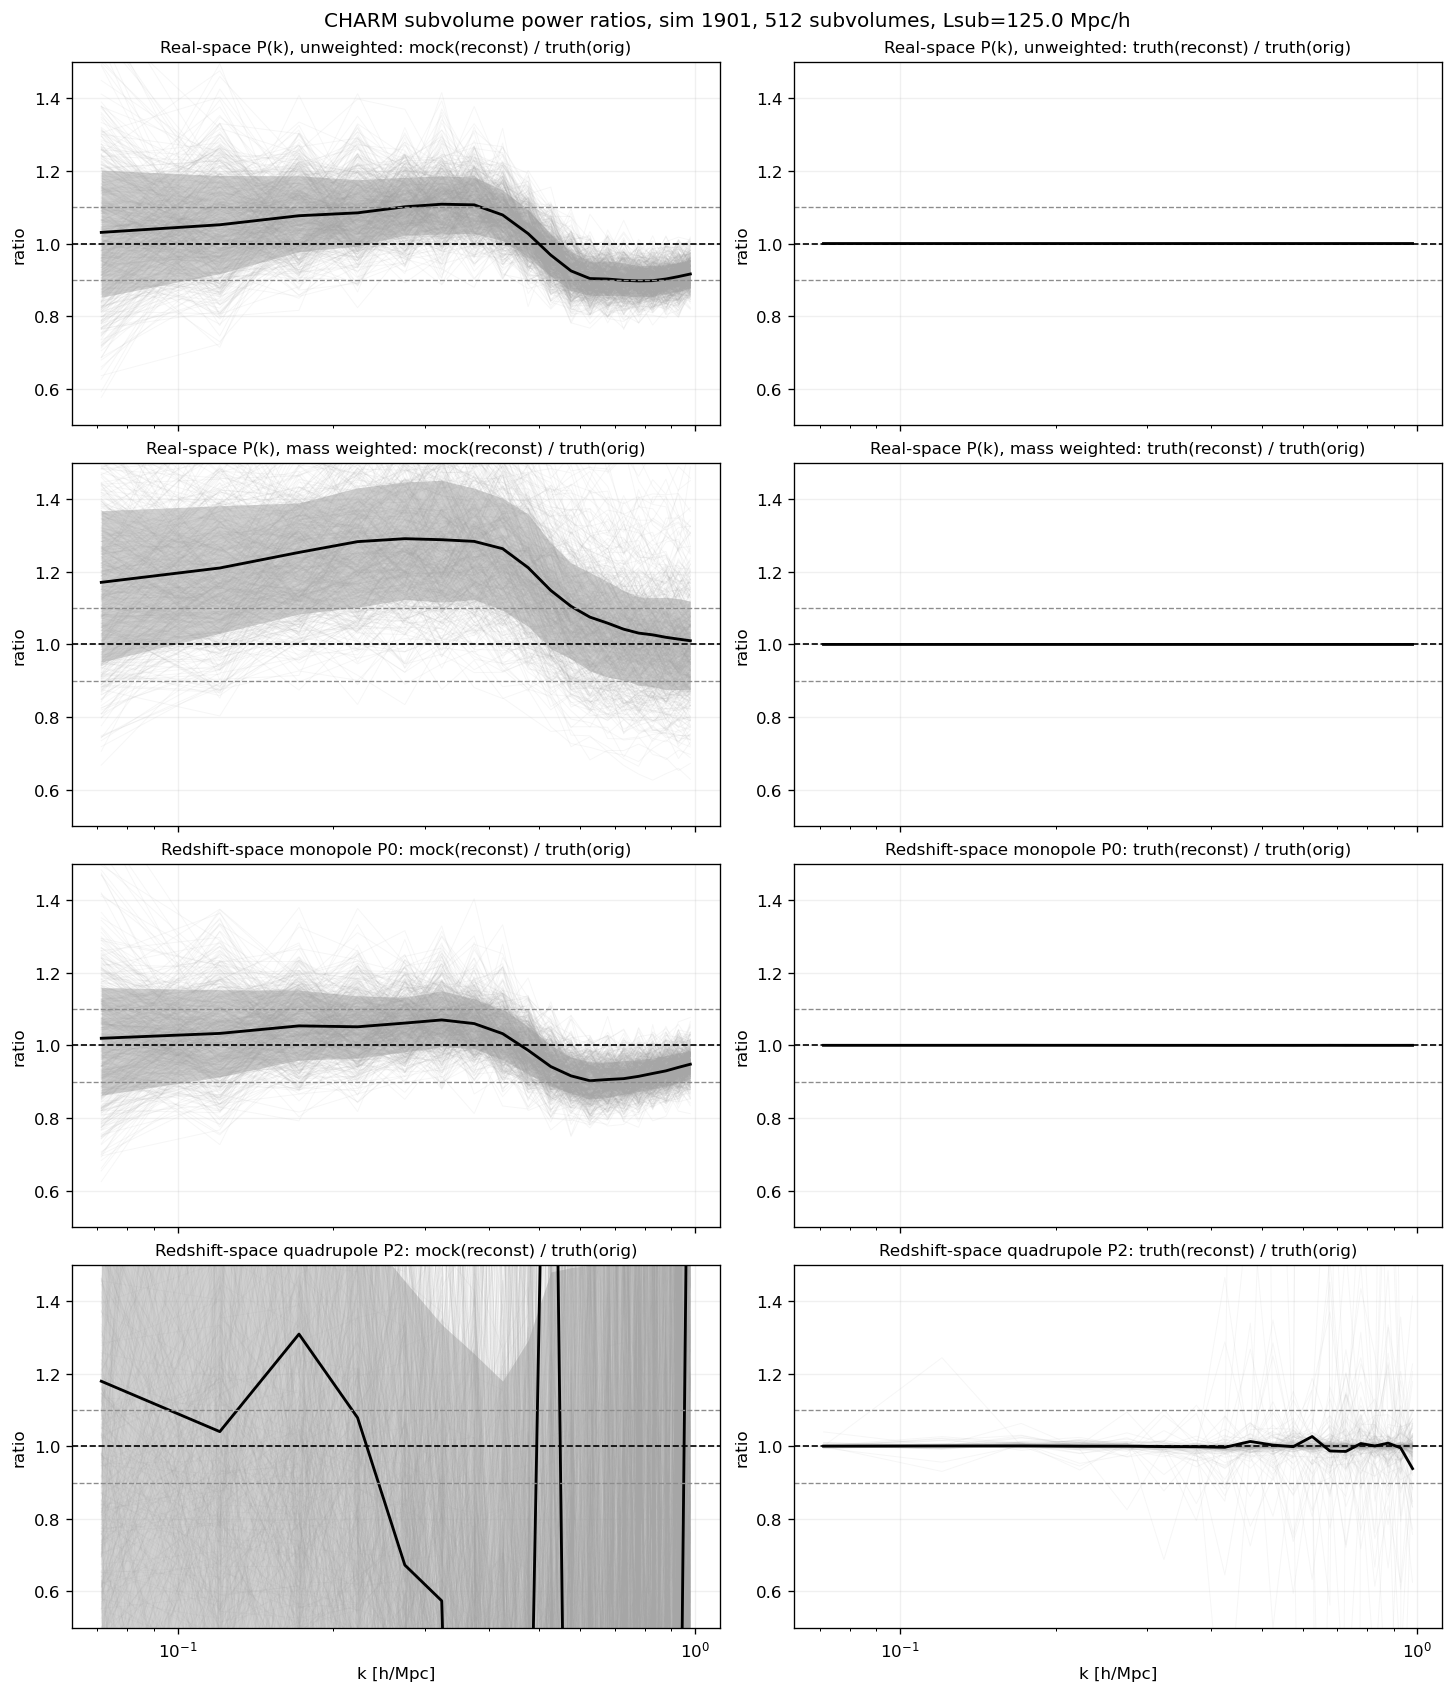

Saved figure to /mnt/ceph/users/spandey/CHARM_v2/CHARM/notebooks/testing/reconstruct_subvolume_power_ratios.png


In [12]:
def draw_ratio_panel(ax, k, ratios, title):
    """Draw all subvolume ratios, mean, and 16-84 percentile band."""
    for row in ratios:
        ax.plot(k, row, color="0.65", alpha=0.10, lw=0.55)

    mean = np.nanmean(ratios, axis=0)
    p16, p84 = np.nanpercentile(ratios, [16, 84], axis=0)
    ax.fill_between(k, p16, p84, color="black", alpha=0.18, lw=0)
    ax.plot(k, mean, color="black", lw=1.7)

    ax.axhline(1.0, color="black", ls="--", lw=1.0)
    ax.axhline(0.9, color="0.55", ls="--", lw=0.8)
    ax.axhline(1.1, color="0.55", ls="--", lw=0.8)
    ax.set_xscale("log")
    ax.set_ylim(*RATIO_YLIM)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("ratio")


fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(12, 14),
    sharex=True,
    constrained_layout=True,
)

for row, (stat_key, stat_label) in enumerate(stat_specs):
    k = ratio_results[stat_key]["k"]
    draw_ratio_panel(
        axes[row, 0],
        k,
        ratio_results[stat_key]["mock_reconst"],
        f"{stat_label}: mock(reconst) / truth(orig)",
    )
    draw_ratio_panel(
        axes[row, 1],
        k,
        ratio_results[stat_key]["truth_reconst"],
        f"{stat_label}: truth(reconst) / truth(orig)",
    )

for ax in axes[-1, :]:
    ax.set_xlabel("k [h/Mpc]")

fig.suptitle(
    f"CHARM subvolume power ratios, sim {SIM_ID}, "
    f"{nsubs} subvolumes, Lsub={Lsub:.1f} Mpc/h",
    fontsize=12,
)
FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
# fig.savefig(FIG_PATH, bbox_inches="tight")
plt.show()
print(f"Saved figure to {FIG_PATH}")
